# Process GPSd Output

The purpose of this notebook is to process GPSd output which was captured using the script [RecordGPS.sh](./RecordGPS.sh).

For more information on [GPSd](https://gpsd.io/)


In [1]:
import json
import pandas as pd
import geopandas as gpd
import shapely
import pyproj

In [2]:
crs = pyproj.CRS.from_string('WGS84')

In [3]:
decoder = json.JSONDecoder()
def convertDataSet(file):
    objs = []
    with open(file) as f:
        for line in f.readlines():
            obj = decoder.decode(line)
            if obj['class'] == 'TPV':
                objs.append(obj)

    frame = pd.DataFrame.from_dict(objs)
    frame['time'] = pd.to_datetime( frame['time'] )

    return frame
        

In [4]:
data = convertDataSet('./datasets/GPS_2026-08-03.out')
data.head()

,class,device,mode,antPwr,jam,time,ept,lat,lon,altHAE,...,ecefpAcc,ecefvAcc,velN,velE,velD,geoidSep,epd,epc,leapseconds,status
0,TPV,/dev/ttyACM0,1,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TPV,/dev/ttyACM0,1,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TPV,/dev/ttyACM0,1,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TPV,/dev/ttyACM0,0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TPV,/dev/ttyACM0,1,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
data['time'].min()

Timestamp('2026-08-03 16:17:44+0000', tz='UTC')

In [6]:
sorted(list(data.columns))

['alt',
 'altHAE',
 'altMSL',
 'antPwr',
 'class',
 'climb',
 'clockbias',
 'clockdrift',
 'device',
 'ecefpAcc',
 'ecefvAcc',
 'ecefvx',
 'ecefvy',
 'ecefvz',
 'ecefx',
 'ecefy',
 'ecefz',
 'epc',
 'epd',
 'eph',
 'eps',
 'ept',
 'epv',
 'epx',
 'epy',
 'geoidSep',
 'jam',
 'lat',
 'leapseconds',
 'lon',
 'magtrack',
 'magvar',
 'mode',
 'sep',
 'speed',
 'status',
 'time',
 'track',
 'velD',
 'velE',
 'velN']

In [7]:
#mode 3 are the datapoints wer are after.  
#mode 1 is just time, mode to is a 2D location fix, 
#and while we are working with 2D, 
#it indicates that its not a very good fix so we wont use those either
data['mode'].value_counts()

mode
3    3991
1     337
2      16
0       6
Name: count, dtype: int64

In [8]:
def turnToGeoFrame(frame):
    frameMode3 = frame[frame['mode']==3]

    pts = frameMode3.apply(lambda x: shapely.geometry.Point( (x['lon'], x['lat']) ) ,axis=1)
    
    geoDataFrame = gpd.GeoDataFrame(frameMode3,geometry=pts, crs=crs)
    geoDataFrame.index=geoDataFrame['time']
    del geoDataFrame['time']
    return geoDataFrame

In [9]:
geoData = turnToGeoFrame(data)

<Axes: >

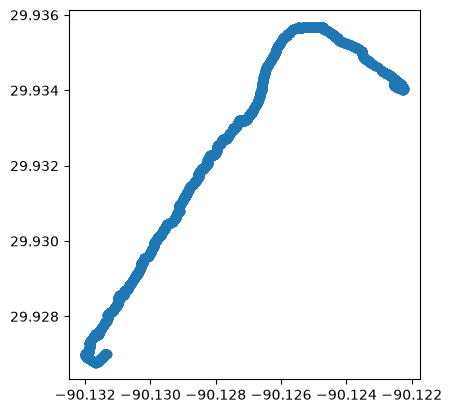

In [10]:
geoData.plot()

<Axes: >

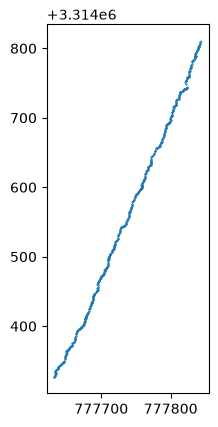

In [11]:
#from a GPS accurace perspective that line should be pretty straight.
#basically I walked down the center line of a stright sidewalk using the same 
#technique as a sanity check
testSet = turnToGeoFrame(convertDataSet('./datasets/GPS_TEST_2026-08-03.out')).iloc[200:-100]
testSet = testSet.to_crs(pyproj.CRS.from_epsg(32615))
testSet.plot(marker='.',markersize=0.5)

In [12]:
geoData.to_file('./datasets/GPS_2026-08-03.geojson')